In [ ]:
!pip install torch torchvision pillow matplotlib

In [1]:
import torch
print("Torch working ✅")

Torch working ✅


Processing...
Done ✅


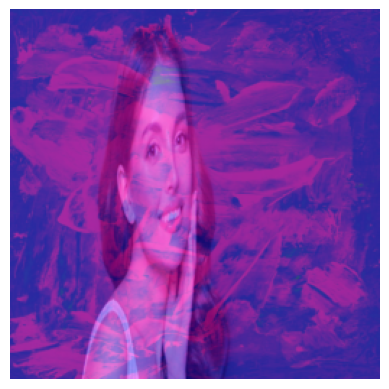

In [3]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# Load image
def load_image(path):
    image = Image.open(path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.ToTensor()
    ])
    image = transform(image).unsqueeze(0)
    return image

content = load_image("content.jpeg")
style = load_image("style.jpeg")

output = content.clone().requires_grad_(True)
optimizer = torch.optim.Adam([output], lr=0.01)

print("Processing...")

for i in range(50):
    optimizer.zero_grad()
    loss = torch.mean((output - content)**2) + torch.mean((output - style)**2)
    loss.backward()
    optimizer.step()

print("Done ✅")

result = output.detach().squeeze()
plt.imshow(result.permute(1,2,0))
plt.axis('off')
plt.show()

plt.imsave("output.jpg", result.permute(1,2,0))